# CMM704 Data Mining : Question 1 Regression with Catboost
#### Fouzul Hassan
##### RGU No : 2410544 / IIT No : 20233214

## Data loading



In [ ]:
import pandas as pd

df = pd.read_csv('ds_salaries.csv')
display(df.head())
print(df.shape)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000.0,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000.0,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500.0,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000.0,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000.0,USD,120000,CA,100,CA,M


(3755, 11)


## Data exploration



## Data cleaning


Check for missing values and duplicates, then apply imputation and remove duplicates.



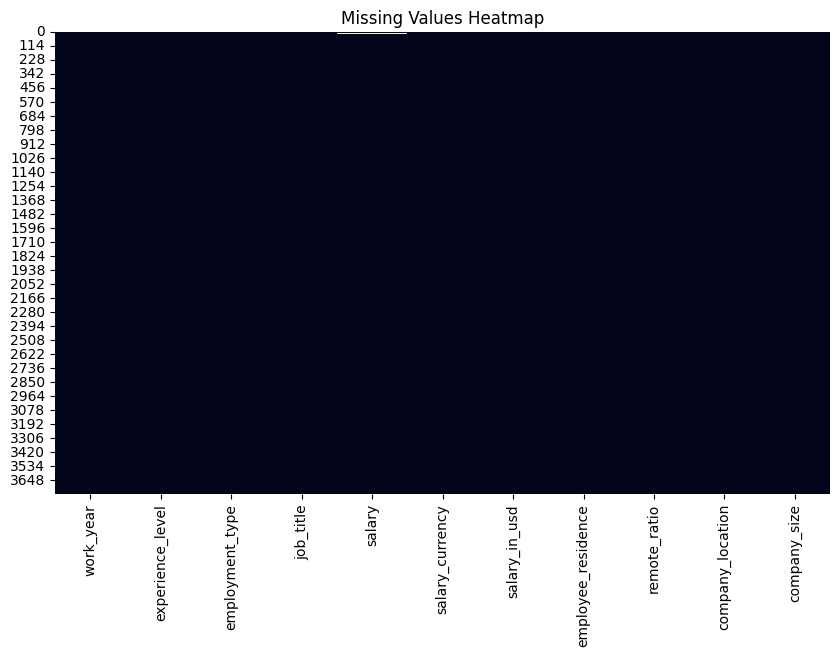

In [ ]:
#heatmap for missing value percentage
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
df = df.drop_duplicates()
print(df.shape)

(2588, 11)


In [ ]:
#number of missing values
missing_values = df.isnull().sum()
print(missing_values)

work_year             0
experience_level      3
employment_type       3
job_title             5
salary                4
salary_currency       0
salary_in_usd         0
employee_residence    1
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [ ]:
#percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

work_year             0.000000
experience_level      0.115920
employment_type       0.115920
job_title             0.193199
salary                0.154560
salary_currency       0.000000
salary_in_usd         0.000000
employee_residence    0.038640
remote_ratio          0.000000
company_location      0.000000
company_size          0.000000
dtype: float64


In [ ]:
df.isnull().corr().round(4)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
work_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_level,NaN,1.0000,-0.0012,-0.0015,-0.0013,NaN,NaN,-0.0007,NaN,NaN,NaN
employment_type,NaN,-0.0012,1.0000,-0.0015,-0.0013,NaN,NaN,-0.0007,NaN,NaN,NaN
job_title,NaN,-0.0015,-0.0015,1.0000,-0.0017,NaN,NaN,-0.0009,NaN,NaN,NaN
salary,NaN,-0.0013,-0.0013,-0.0017,1.0000,NaN,NaN,-0.0008,NaN,NaN,NaN
salary_currency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employee_residence,NaN,-0.0007,-0.0007,-0.0009,-0.0008,NaN,NaN,1.0000,NaN,NaN,NaN
remote_ratio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_location,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


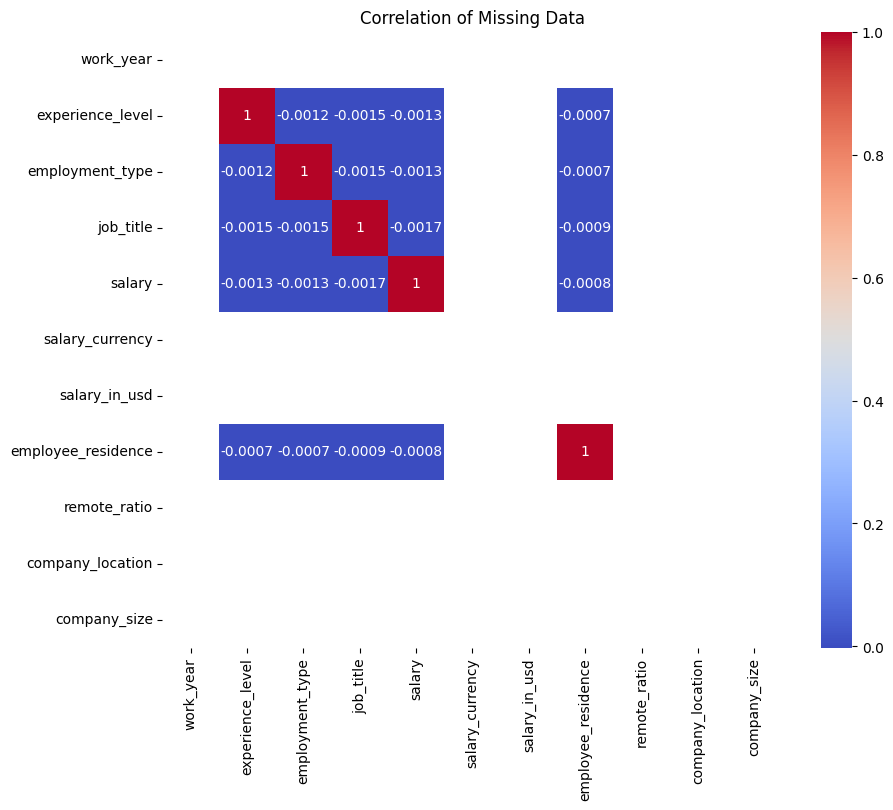

In [ ]:
corr_matrix = df.isnull().corr().round(4)
#increase the correlation box size
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation of Missing Data")
plt.show()

In [ ]:
# Keep only rows where experience_level is null
df_missing_experience = df[df["experience_level"].isnull()]
df_missing_experience

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
98,2023,NaN,FT,Data Engineer,185000.0,USD,185000,US,100,US,M
106,2023,NaN,FT,Data Engineer,94300.0,USD,94300,US,0,US,M
118,2023,NaN,FT,Analytics Engineer,214000.0,USD,214000,US,0,US,M


In [ ]:
# Keep only rows where employment_type is null
df_missing_employment_type = df[df["employment_type"].isnull()]
df_missing_employment_type

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
93,2023,SE,NaN,Data Scientist,105000.0,USD,105000,US,0,US,M
354,2023,SE,NaN,Data Scientist,185900.0,USD,185900,US,0,US,M
358,2023,SE,NaN,Machine Learning Engineer,304000.0,USD,304000,US,100,US,M


In [ ]:
# Keep only rows where job_title is null
df_missing_job_title = df[df["job_title"].isnull()]
df_missing_job_title

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
23,2023,SE,FT,NaN,230000.0,USD,230000,GB,100,GB,M
60,2023,SE,FT,NaN,231500.0,USD,231500,US,100,US,M
71,2023,SE,FT,NaN,81500.0,USD,81500,US,0,US,M
110,2023,SE,FT,NaN,133800.0,USD,133800,US,0,US,M
360,2023,MI,FT,NaN,45000.0,EUR,48289,ES,100,ES,M


In [ ]:
# Keep only rows where salary is null
df_missing_salary = df[df["salary"].isnull()]
df_missing_salary

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
16,2023,SE,FT,Data Modeler,NaN,USD,90700,US,0,US,M
41,2022,MI,FT,Machine Learning Engineer,NaN,INR,20984,IN,50,IN,L
364,2023,SE,FT,Data Scientist,NaN,USD,110000,US,100,US,M
376,2023,SE,FT,Data Analytics Manager,NaN,USD,120000,US,100,US,M


In [ ]:
# Keep only rows where salary is null
df_missing_employee_residence = df[df["employee_residence"].isnull()]
df_missing_employee_residence

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
29,2023,SE,FT,Data Strategist,90000.0,USD,90000,NaN,0,CA,M


### Handeling Missing Values

In [ ]:
df.shape

(2588, 11)

employee_residence is has missing value less than 5%, it is a categorical variale, therefore imputing with mode

In [ ]:
#impute employee residence with mode
df['employee_residence'].fillna(df['employee_residence'].mode()[0], inplace=True)

# verify employee residence doesnt have any missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
work_year             0
experience_level      3
employment_type       3
job_title             5
salary                4
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


<ipython-input-15-fa20c26729ef>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['employee_residence'].fillna(df['employee_residence'].mode()[0], inplace=True)


experience_level,employment_type,job_title, salary are contains missing values 5-20%, therefore considering KNN imputation

In [ ]:
#knn imputation for experience_level,employment_type,job_title, salary
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

# Columns with missing values
missing_columns = ["experience_level", "employment_type", "job_title", "salary"]

# Encode categorical columns to numerical values
label_encoders = {}

for col in ["experience_level", "employment_type", "job_title", "salary_currency", "employee_residence", "company_location", "company_size"]: # Include all your categorical features here
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = df[col].replace("nan", np.nan)
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Apply KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Convert categorical columns back to original labels
for col in ["experience_level", "employment_type", "job_title", "salary_currency", "employee_residence", "company_location", "company_size"]: # Include all your categorical features here
    df_imputed[col] = df_imputed[col].round().astype(int)
    df_imputed[col] = label_encoders[col].inverse_transform(df_imputed[col])

df = df_imputed

In [ ]:
# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


#Data Preprocessing

In [ ]:
#drop 'nan'
df = df[df['experience_level'] != 'nan']

In [ ]:
#drop 'nan'
df = df[df['employment_type'] != 'nan']

In [ ]:
#drop 'nan'
df = df[df['job_title'] != 'nan']

In [ ]:
pd.set_option('display.max_rows', 100)

job_title_counts = df['job_title'].value_counts(dropna=False)
job_title_percentages = (job_title_counts / len(df)) * 100
job_title_summary = pd.DataFrame({
    'Count': job_title_counts,
    'Percentage': job_title_percentages.round(2)
})
job_title_summary = job_title_summary.sort_values(by='Count', ascending=False)

# Display
print(f"Total Unique Job Titles: {job_title_summary.shape[0]}")
print(job_title_summary)


Total Unique Job Titles: 93
                                          Count  Percentage
job_title                                                  
Data Engineer                               594       23.05
Data Scientist                              539       20.92
Data Analyst                                396       15.37
Machine Learning Engineer                   205        7.95
Analytics Engineer                           89        3.45
Research Scientist                           65        2.52
Data Architect                               64        2.48
Data Science Manager                         52        2.02
ML Engineer                                  34        1.32
Research Engineer                            33        1.28
Applied Scientist                            31        1.20
Machine Learning Scientist                   26        1.01
Data Manager                                 23        0.89
Data Science Consultant                      23        0.89
Computer Vis

In [ ]:
# Job title mapping
job_title_mapping = {
    # Data Scientist Related
    'Data Scientist': 'Data Scientist',
    'Applied Data Scientist': 'Data Scientist',
    'Research Scientist': 'Data Scientist',
    'Machine Learning Scientist': 'Data Scientist',
    'Staff Data Scientist': 'Data Scientist',
    'Lead Data Scientist': 'Data Scientist',
    'Product Data Scientist': 'Data Scientist',
    'Data Science Consultant': 'Data Scientist',
    'Data Science Engineer': 'Data Scientist',
    'Principal Data Scientist': 'Data Scientist',
    'Data Science Lead': 'Data Scientist',
    'Data Science Tech Lead': 'Data Scientist',

    # Data Engineer Related
    'Data Engineer': 'Data Engineer',
    'Cloud Data Engineer': 'Data Engineer',
    'Software Data Engineer': 'Data Engineer',
    'ETL Developer': 'Data Engineer',
    'ETL Engineer': 'Data Engineer',
    'Data Infrastructure Engineer': 'Data Engineer',
    'Data Operations Engineer': 'Data Engineer',
    'BI Data Engineer': 'Data Engineer',
    'Azure Data Engineer': 'Data Engineer',

    # Data Analyst Related
    'Data Analyst': 'Data Analyst',
    'BI Analyst': 'Data Analyst',
    'BI Data Analyst': 'Data Analyst',
    'Business Data Analyst': 'Data Analyst',
    'Compliance Data Analyst': 'Data Analyst',
    'Product Data Analyst': 'Data Analyst',
    'Financial Data Analyst': 'Data Analyst',
    'Staff Data Analyst': 'Data Analyst',
    'Insight Analyst': 'Data Analyst',

    # Machine Learning Engineers
    'Machine Learning Engineer': 'ML Engineer',
    'ML Engineer': 'ML Engineer',
    'Applied Machine Learning Engineer': 'ML Engineer',
    'Applied Machine Learning Scientist': 'ML Engineer',
    'Deep Learning Engineer': 'ML Engineer',
    'Deep Learning Researcher': 'ML Engineer',
    'Machine Learning Developer': 'ML Engineer',
    'NLP Engineer': 'ML Engineer',
    'Machine Learning Researcher': 'ML Engineer',
    'Machine Learning Research Engineer': 'ML Engineer',
    'Lead Machine Learning Engineer': 'ML Engineer',
    'Principal Machine Learning Engineer': 'ML Engineer',
    'Machine Learning Infrastructure Engineer': 'ML Engineer',
    'Machine Learning Software Engineer': 'ML Engineer',

    # Analytics Related
    'Analytics Engineer': 'Analytics',
    'Data Analytics Engineer': 'Analytics',
    'Data Analytics Lead': 'Analytics',
    'Data Analytics Manager': 'Analytics',
    'Data Analytics Consultant': 'Analytics',
    'Data Analytics Specialist': 'Analytics',

    # Architect Related
    'Data Architect': 'Architect',
    'Cloud Data Architect': 'Architect',
    'Principal Data Architect': 'Architect',
    'Big Data Architect': 'Architect',

    # Managerial Roles
    'Data Science Manager': 'Management',
    'Machine Learning Manager': 'Management',
    'Data Manager': 'Management',
    'Head of Data': 'Management',
    'Head of Data Science': 'Management',
    'Head of Machine Learning': 'Management',
    'Manager Data Management': 'Management',
    'Director of Data Science': 'Management',

    # AI Specialist Roles
    'AI Developer': 'AI Specialist',
    'AI Scientist': 'AI Specialist',
    'AI Programmer': 'AI Specialist',

    # Others
    'Computer Vision Engineer': 'Other',
    'Computer Vision Software Engineer': 'Other',
    '3D Computer Vision Researcher': 'Other',
    'Autonomous Vehicle Technician': 'Other',
    'Data Strategist': 'Other',
    'Data Operations Analyst': 'Other',
    'Cloud Database Engineer': 'Other',
    'Power BI Developer': 'Other',
    'Marketing Data Analyst': 'Other',
    'Marketing Data Engineer': 'Other',
    'Data Management Specialist': 'Other',
    'Big Data Engineer': 'Other',
    'Data Modeler': 'Other',
    'Finance Data Analyst': 'Other'
}

# Apply the mapping
df['job_title_grouped'] = df['job_title'].map(job_title_mapping)

# Fill unmapped jobs with 'Other'
df['job_title_grouped'] = df['job_title_grouped'].fillna('Other')


In [ ]:
pd.set_option('display.max_rows', 100)

job_title_counts = df['job_title_grouped'].value_counts(dropna=False)
job_title_percentages = (job_title_counts / len(df)) * 100
job_title_summary = pd.DataFrame({
    'Count': job_title_counts,
    'Percentage': job_title_percentages.round(2)
})
job_title_summary = job_title_summary.sort_values(by='Count', ascending=False)

# Display
print(f"Total Unique Job Titles: {job_title_summary.shape[0]}")
print(job_title_summary)


Total Unique Job Titles: 9
                   Count  Percentage
job_title_grouped                   
Data Scientist       696       27.01
Data Engineer        622       24.14
Data Analyst         447       17.35
ML Engineer          308       11.95
Other                178        6.91
Analytics            119        4.62
Management           110        4.27
Architect             68        2.64
AI Specialist         29        1.13


In [ ]:
geo_columns = ['employee_residence', 'company_location']

def group_rare_labels(df, col, threshold=10):
    value_counts = df[col].value_counts()
    rare_labels = value_counts[value_counts < threshold].index
    df[col] = df[col].apply(lambda x: 'Other' if x in rare_labels else x)
    return df

for col in geo_columns:
    df = group_rare_labels(df, col)

In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_title_grouped
0,2023.0,SE,FT,Principal Data Scientist,80000.0,EUR,85847.0,ES,100.0,ES,L,Data Scientist
1,2023.0,MI,CT,ML Engineer,30000.0,USD,30000.0,US,100.0,US,S,ML Engineer
2,2023.0,MI,CT,ML Engineer,25500.0,USD,25500.0,US,100.0,US,S,ML Engineer
3,2023.0,SE,FT,Data Scientist,175000.0,USD,175000.0,CA,100.0,CA,M,Data Scientist
4,2023.0,SE,FT,Data Scientist,120000.0,USD,120000.0,CA,100.0,CA,M,Data Scientist


## Data analysis

### Subtask:
Analyze the distribution of salary across different job titles, experience levels, employment types, and company sizes. Identify potential outliers in the salary variable.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import normaltest

# Set consistent plot style
sns.set_style("whitegrid")

# 1. Plot Univariate Distributions (Numeric)
def plot_numeric_distributions(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(data=df, x=col, kde=True, bins=20)
        plt.title(f'{col} Distribution', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

        # Normality test
        stat, pval = normaltest(df[col].dropna())
        if pval < 0.05:
            print(f'{col}: Not Gaussian (p={pval:.5f})')
        else:
            print(f'{col}: Gaussian (p={pval:.5f})')
        print('-'*60)

# 2. Plot Boxplots for Numeric Variables
def plot_numeric_boxplots(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=col, data=df)
        plt.title(f'Boxplot of {col}', fontsize=14)
        plt.tight_layout()
        plt.show()


# 3. Plot Salary vs Categorical Variables
def plot_salary_vs_categorical(df, target_column='salary_in_usd'):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=col, y=target_column, data=df, palette='Set2')
        plt.title(f'{target_column} Distribution by {col}', fontsize=14)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 4. Plot Outlier Summary (using IQR)
def plot_outlier_summary(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print("\n=== Outlier Detection Summary ===")
    for col in numeric_cols:
        col_data = df[col].dropna()
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
        print(f"{col}: {outliers} outliers detected")

# 6. Pairplot for Numeric Variables
def plot_pairplot(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    sns.pairplot(df[numeric_cols])
    plt.suptitle('Pairplot of Numeric Features', fontsize=16, y=1.02)
    plt.show()


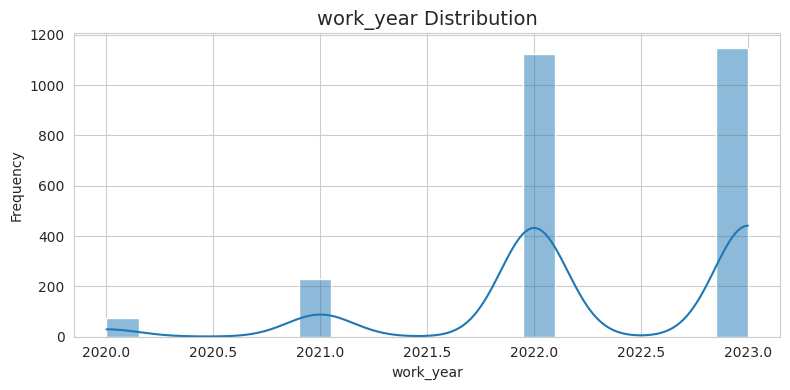

work_year: Not Gaussian (p=0.00000)
------------------------------------------------------------


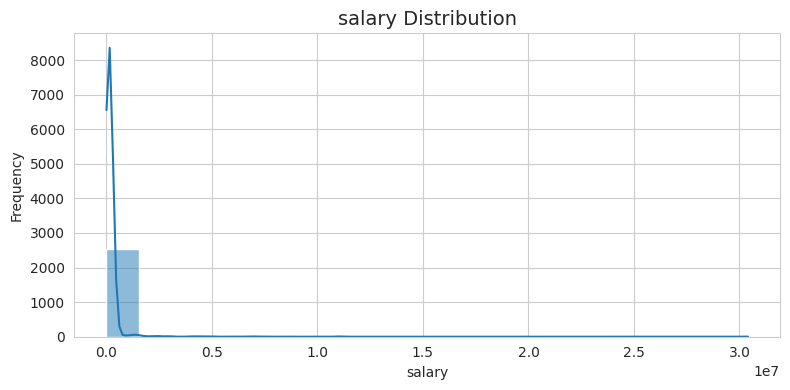

salary: Not Gaussian (p=0.00000)
------------------------------------------------------------


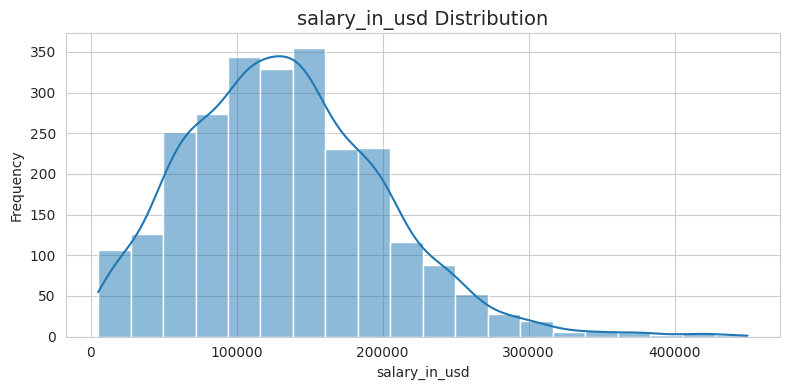

salary_in_usd: Not Gaussian (p=0.00000)
------------------------------------------------------------


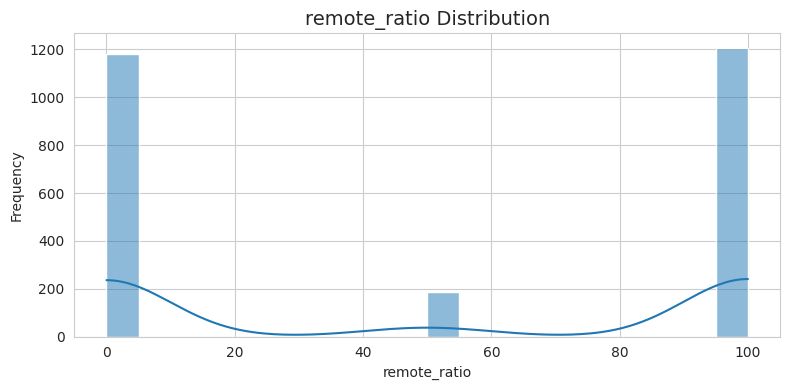

remote_ratio: Not Gaussian (p=0.00000)
------------------------------------------------------------


In [ ]:
plot_numeric_distributions(df)

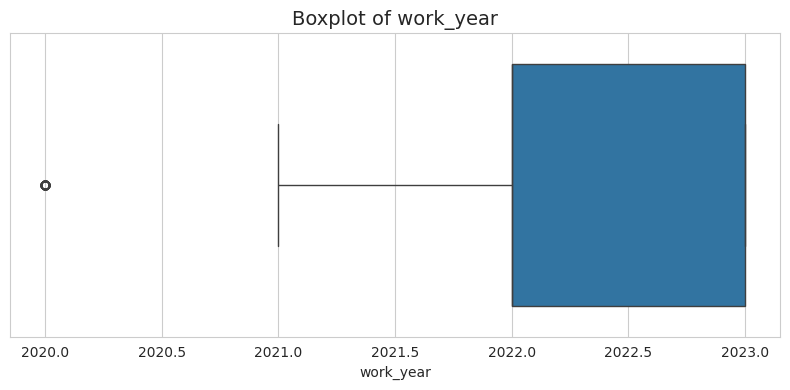

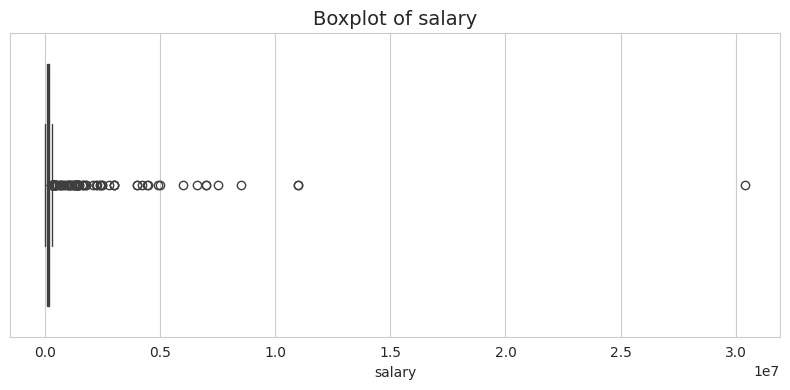

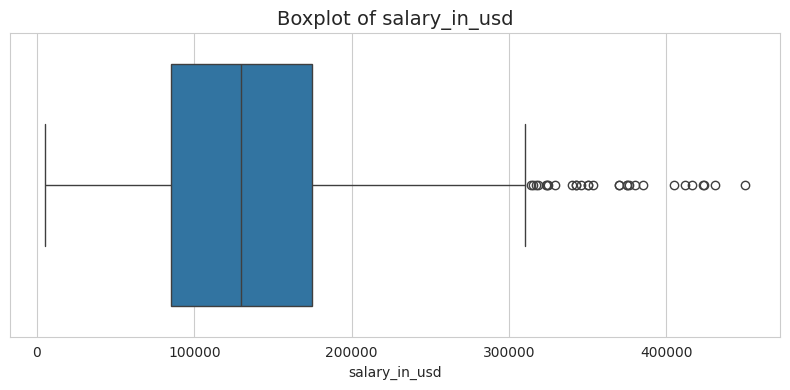

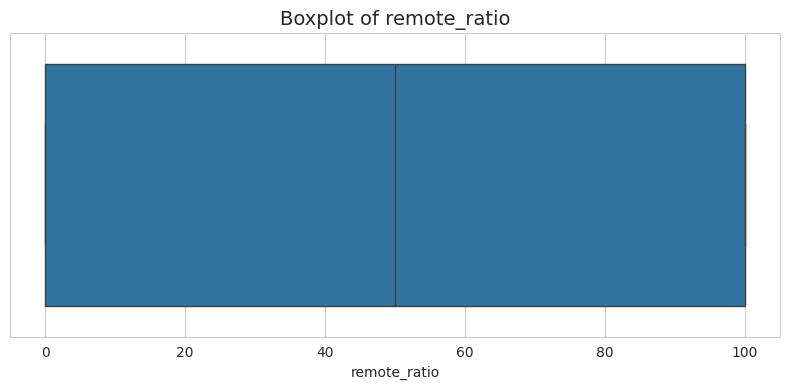

In [ ]:
plot_numeric_boxplots(df)

Found 8 categorical columns.


<ipython-input-29-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


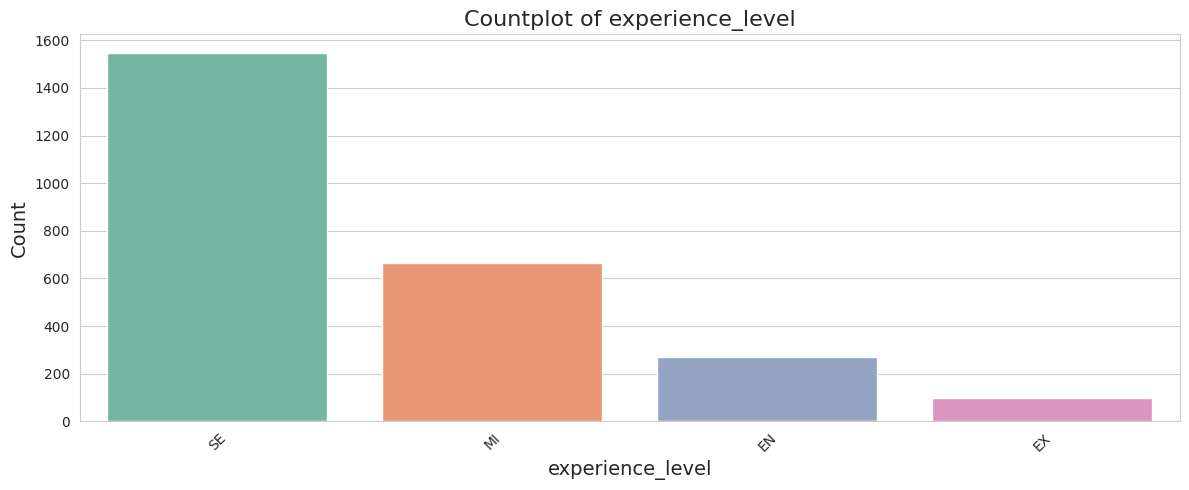

<ipython-input-29-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


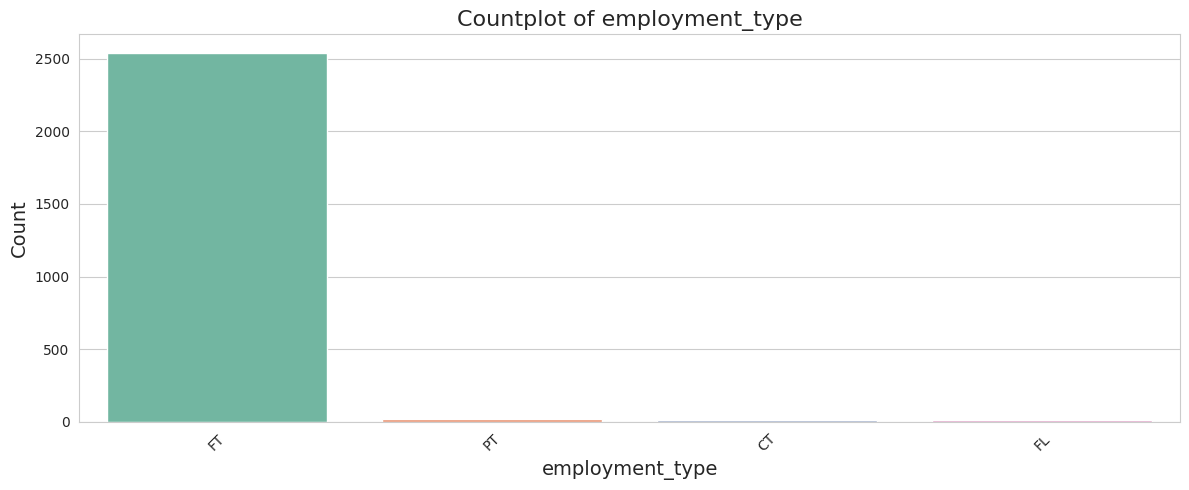

Skipping job_title (too many unique values: 93)


<ipython-input-29-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


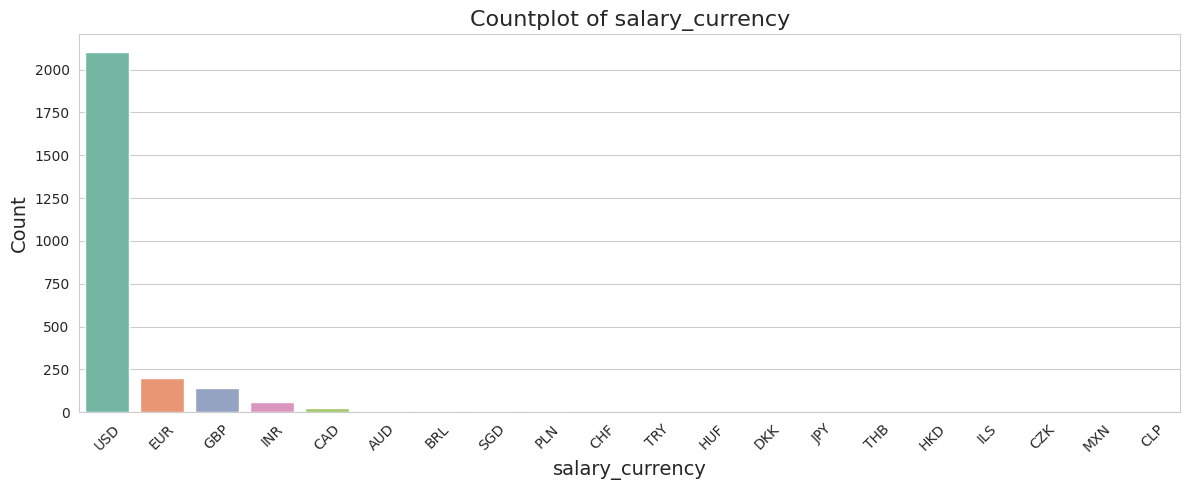

<ipython-input-29-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


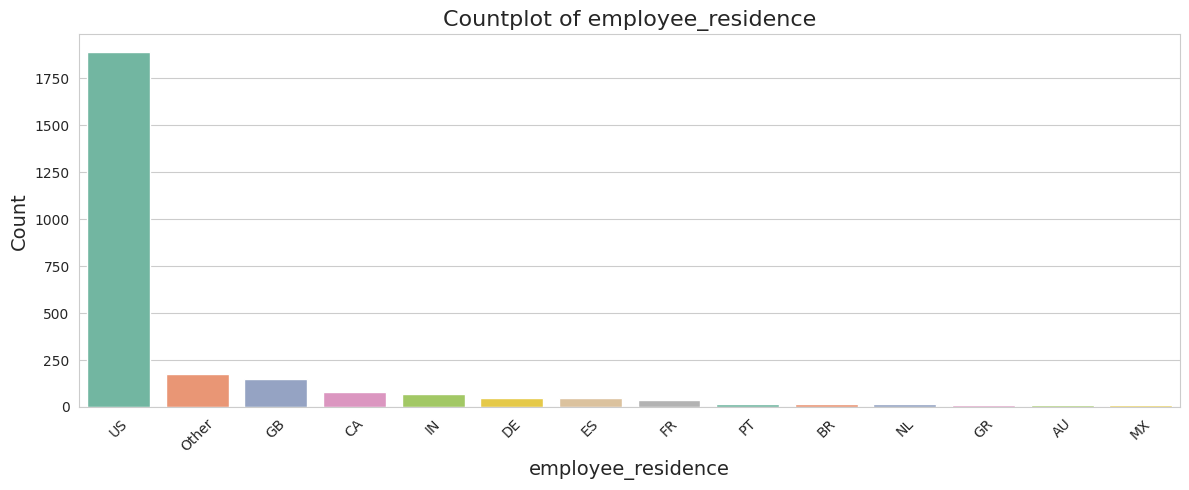

<ipython-input-29-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


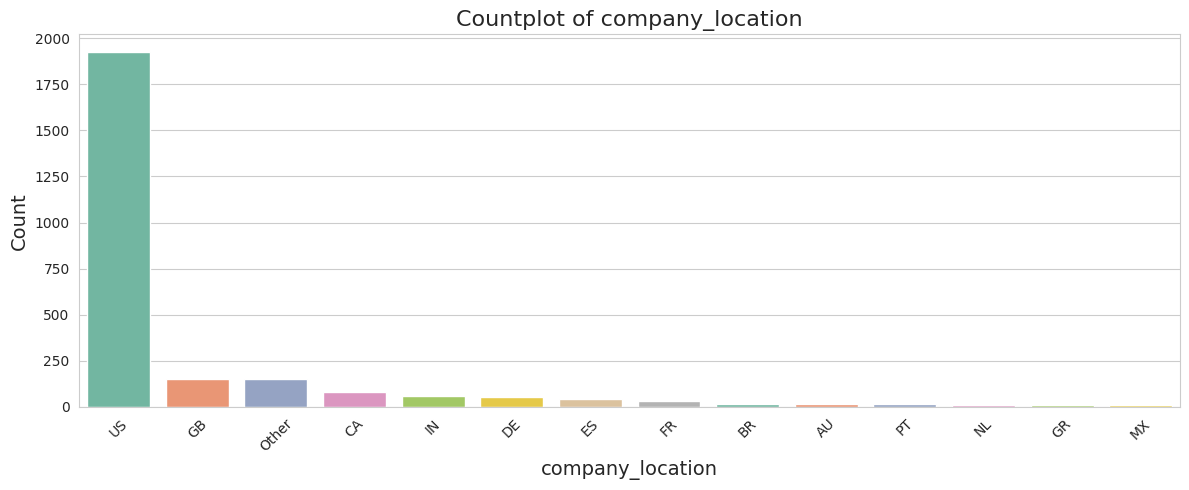

<ipython-input-29-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


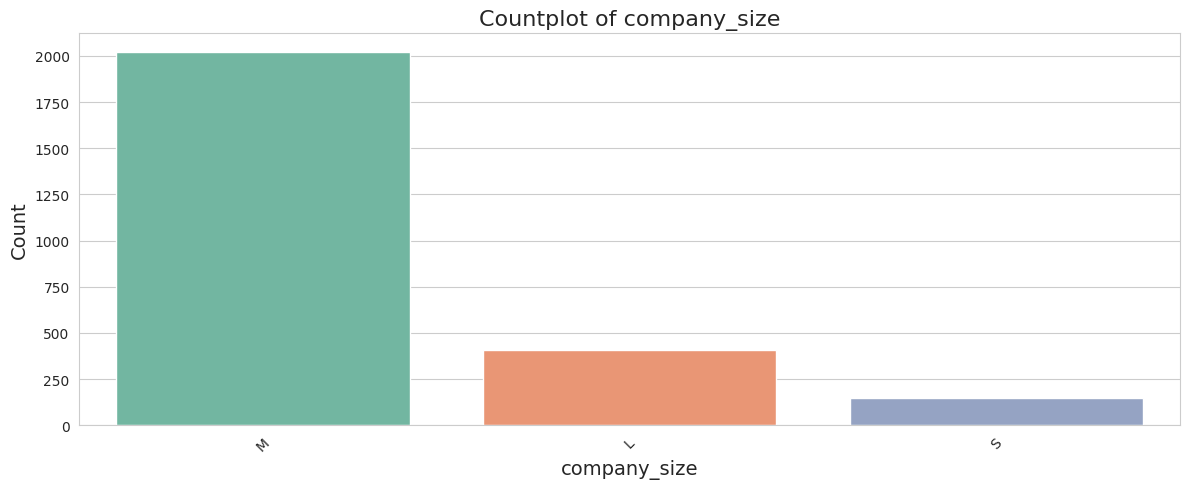

<ipython-input-29-cf1dd4c88324>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)


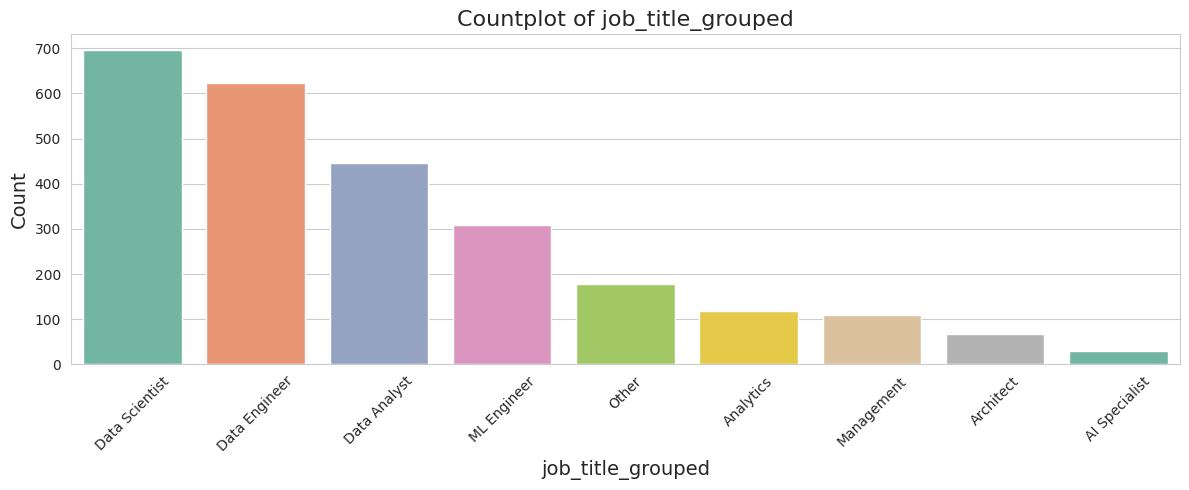

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
def plot_categorical_features(df, max_unique=30):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"Found {len(categorical_cols)} categorical columns.")

    for col in categorical_cols:
        if df[col].nunique() <= max_unique:
            plt.figure(figsize=(12, 5))
            sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)
            plt.title(f'Countplot of {col}', fontsize=16)
            plt.xlabel(col, fontsize=14)
            plt.ylabel('Count', fontsize=14)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print(f"Skipping {col} (too many unique values: {df[col].nunique()})")

plot_categorical_features(df)

In [ ]:
def show_categorical_value_percentages(df):
    dist_check = df.select_dtypes(include=['object', 'category']).columns.tolist()
    # add remote ratio to this categorical_cols
    dist_check.append('remote_ratio')

    for col in dist_check:
        print(f"\nFeature: '{col}'")
        value_counts = df[col].value_counts(dropna=False)
        total = len(df)
        for val, count in value_counts.items():
            percent = (count / total) * 100
            print(f" - {repr(val)}: {count} ({percent:.2f}%)")

show_categorical_value_percentages(df)


Feature: 'experience_level'
 - 'SE': 1548 (60.07%)
 - 'MI': 663 (25.73%)
 - 'EN': 270 (10.48%)
 - 'EX': 96 (3.73%)

Feature: 'employment_type'
 - 'FT': 2540 (98.56%)
 - 'PT': 17 (0.66%)
 - 'CT': 10 (0.39%)
 - 'FL': 10 (0.39%)

Feature: 'job_title'
 - 'Data Engineer': 594 (23.05%)
 - 'Data Scientist': 539 (20.92%)
 - 'Data Analyst': 396 (15.37%)
 - 'Machine Learning Engineer': 205 (7.95%)
 - 'Analytics Engineer': 89 (3.45%)
 - 'Research Scientist': 65 (2.52%)
 - 'Data Architect': 64 (2.48%)
 - 'Data Science Manager': 52 (2.02%)
 - 'ML Engineer': 34 (1.32%)
 - 'Research Engineer': 33 (1.28%)
 - 'Applied Scientist': 31 (1.20%)
 - 'Machine Learning Scientist': 26 (1.01%)
 - 'Data Manager': 23 (0.89%)
 - 'Data Science Consultant': 23 (0.89%)
 - 'Computer Vision Engineer': 18 (0.70%)
 - 'Data Analytics Manager': 18 (0.70%)
 - 'AI Scientist': 16 (0.62%)
 - 'BI Data Analyst': 15 (0.58%)
 - 'Business Data Analyst': 15 (0.58%)
 - 'Applied Machine Learning Scientist': 12 (0.47%)
 - 'Data Special

<ipython-input-26-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


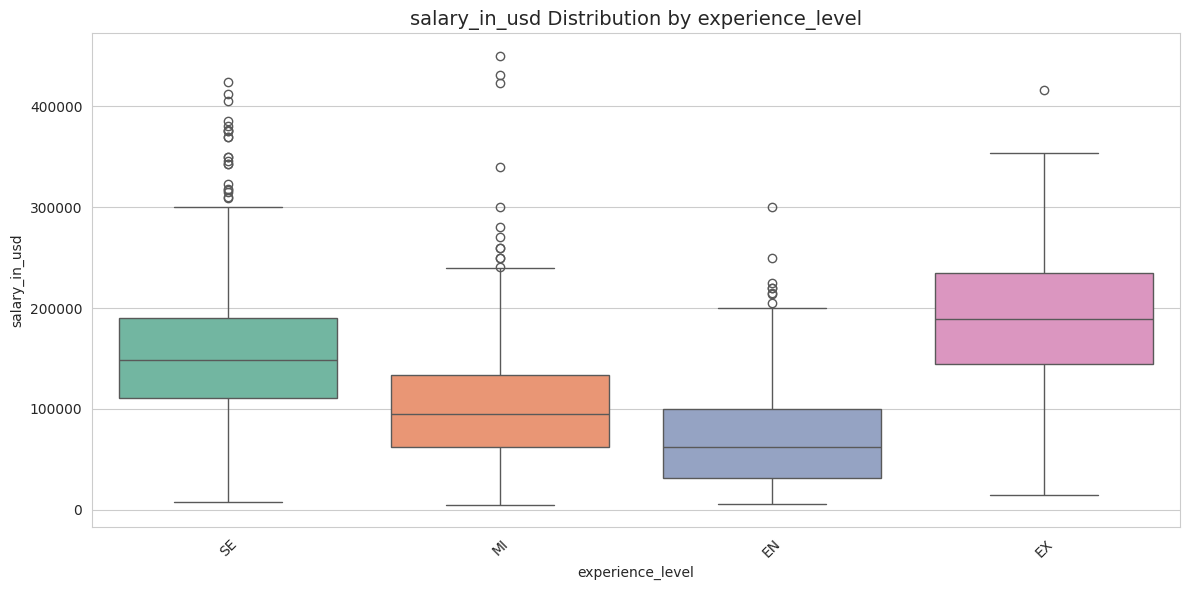

<ipython-input-26-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


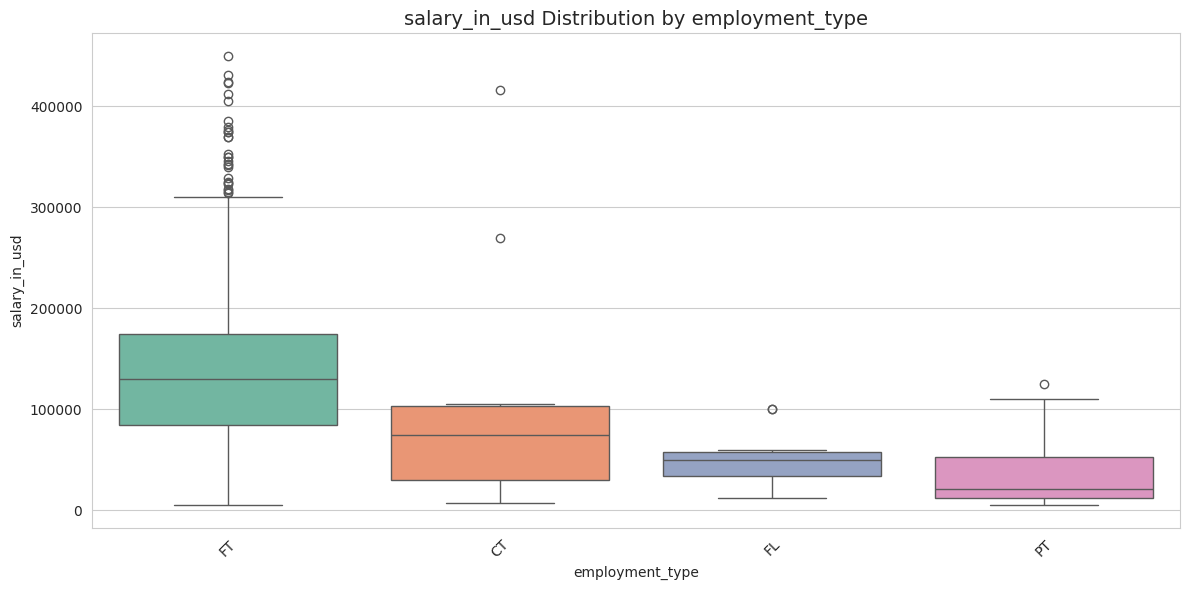

<ipython-input-26-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


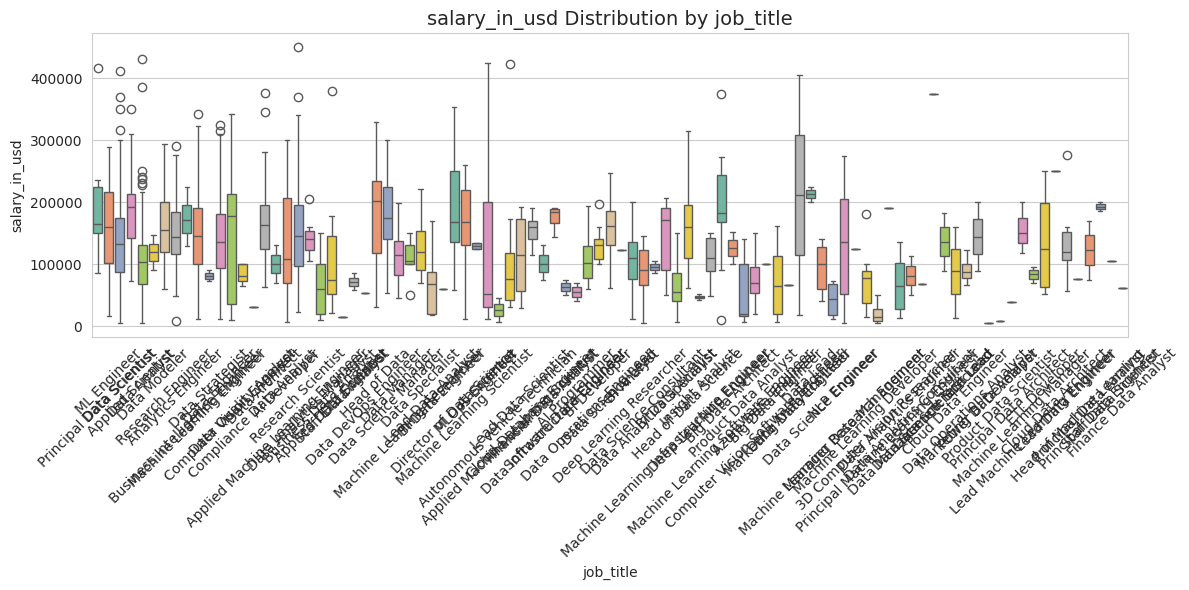

<ipython-input-26-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


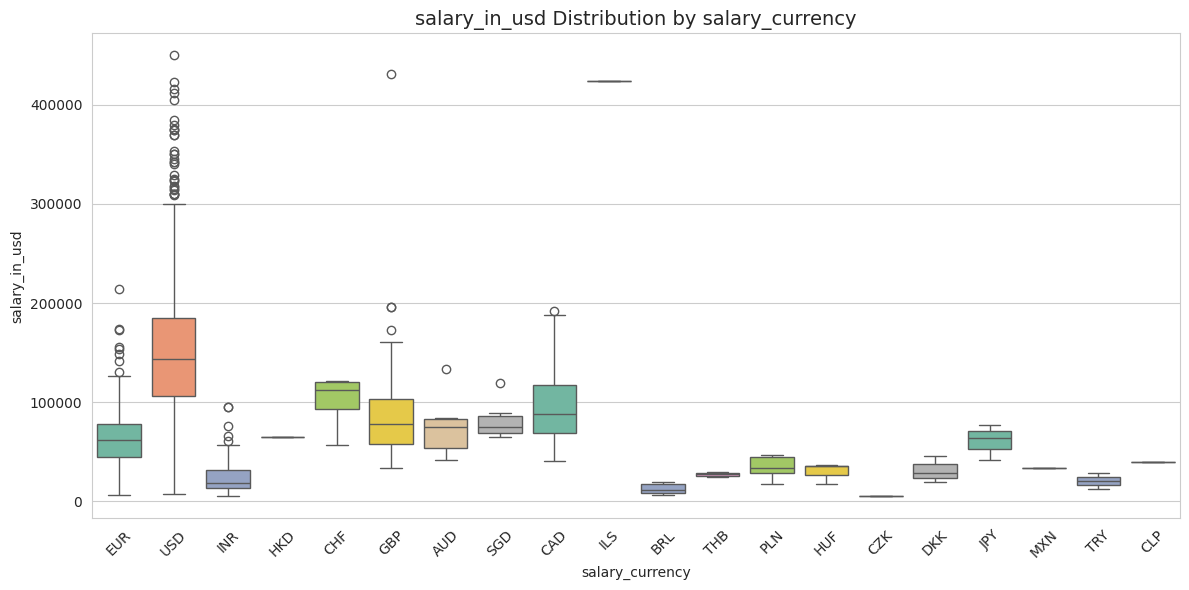

<ipython-input-26-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


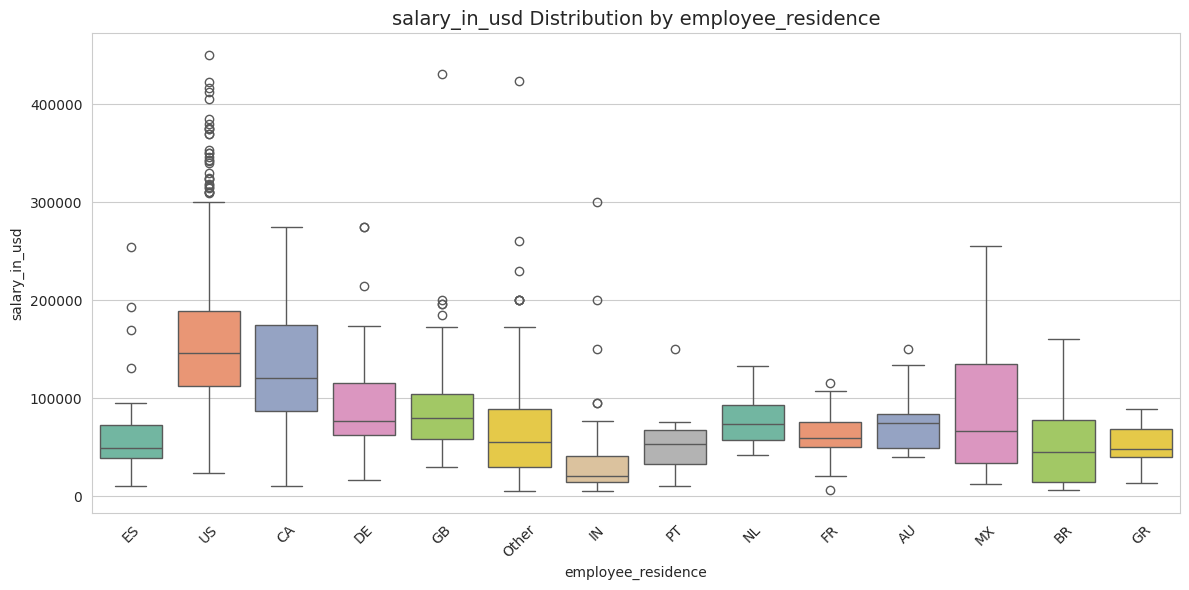

<ipython-input-26-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


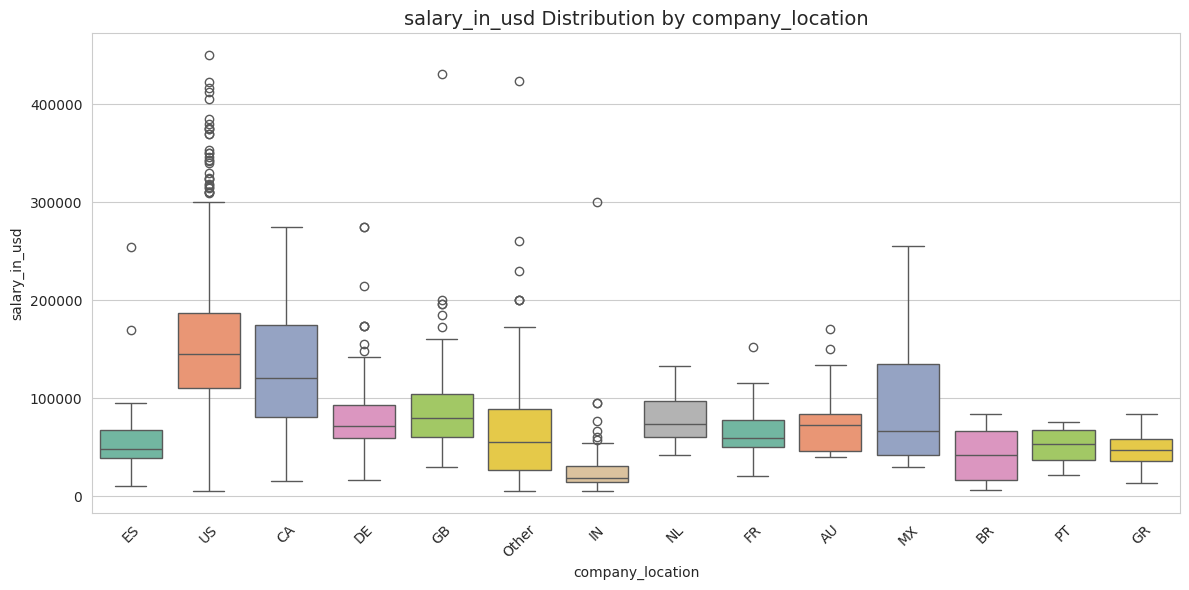

<ipython-input-26-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


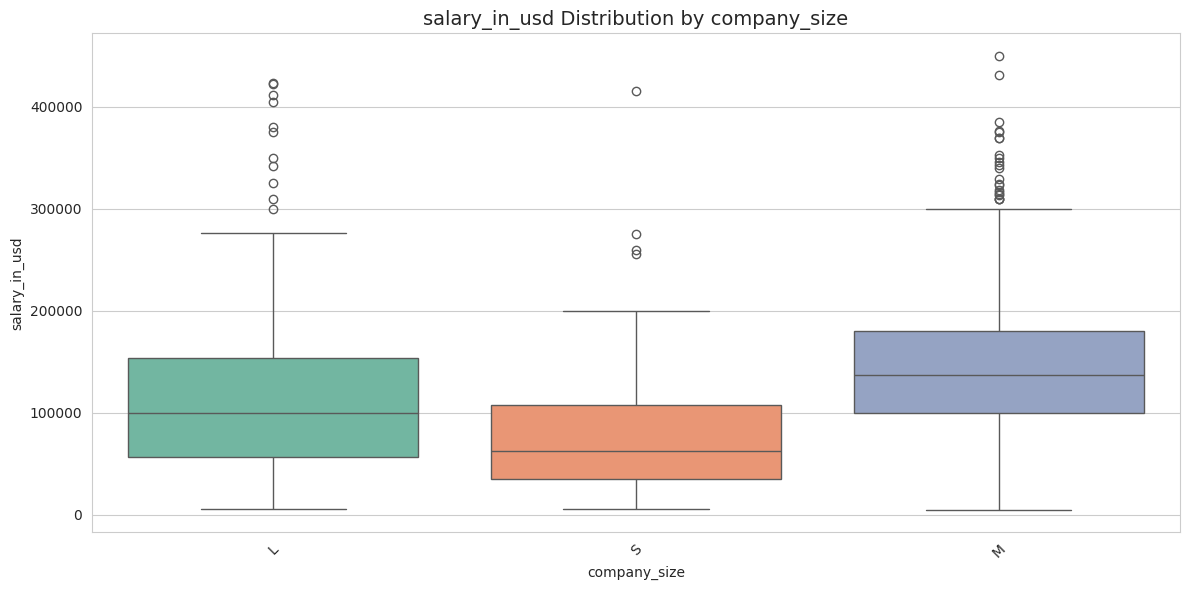

<ipython-input-26-508f72f3d1b1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_column, data=df, palette='Set2')


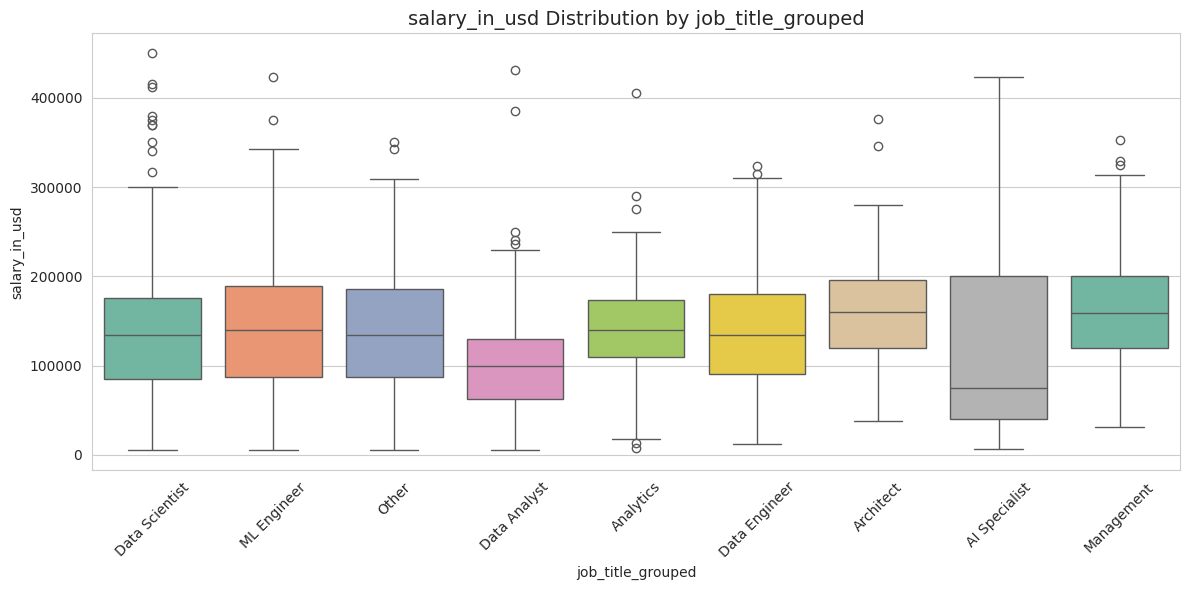

In [ ]:
plot_salary_vs_categorical(df)

In [ ]:
plot_outlier_summary(df)


=== Outlier Detection Summary ===
work_year: 75 outliers detected
salary: 95 outliers detected
salary_in_usd: 29 outliers detected
remote_ratio: 0 outliers detected


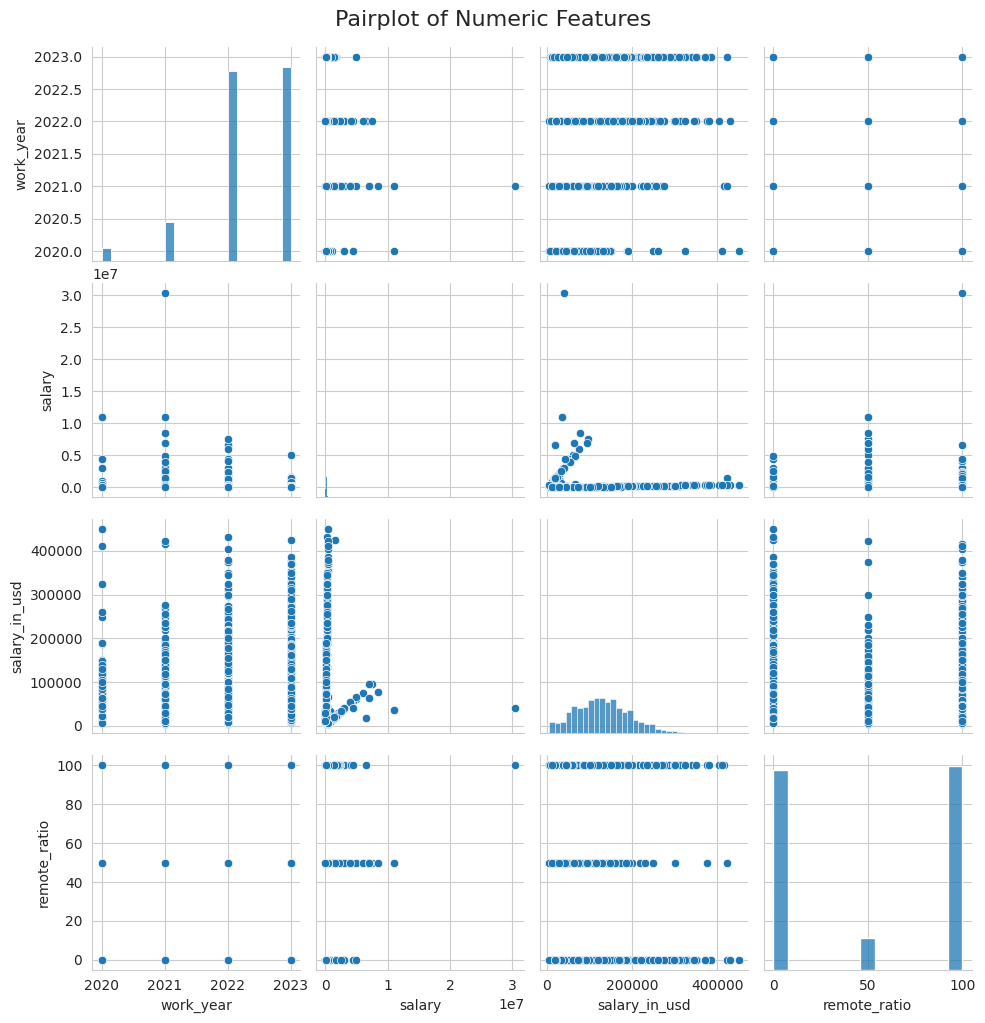

In [ ]:
plot_pairplot(df)

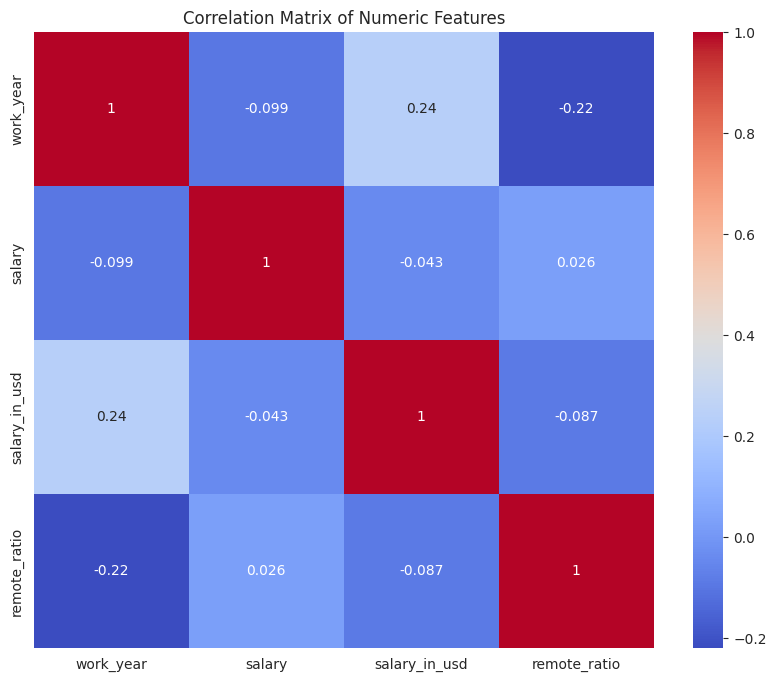

In [ ]:
# 5. Correlation Matrix Heatmap for Numerical
def plot_correlation_matrix(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
    plt.title("Correlation Matrix of Numeric Features")
    plt.show()

plot_correlation_matrix(df)

## Feature Engineering

### Adding New Features

In [ ]:
#Binary Features based on remote work
df['is_remote'] = (df['remote_ratio'] == 100).astype(int)
df['is_onsite'] = (df['remote_ratio'] == 0).astype(int)
df['is_hybrid'] = (df['remote_ratio'] == 50).astype(int)

#Binary Feature for full-time employment
df['is_fulltime'] = (df['employment_type'] == 'FT').astype(int)

In [ ]:
# Binary Feature for Salary Currency
df['is_usd_salary'] = (df['salary_currency'] == 'USD').astype(int)

In [ ]:
#Ordinal Encoding for Experience Level
experience_mapping = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
df['experience_level_encoded'] = df['experience_level'].map(experience_mapping)

# Ordinal Encoding for Company Size
company_size_mapping = {'S': 0, 'M': 1, 'L': 2}
df['company_size_encoded'] = df['company_size'].map(company_size_mapping)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 2587
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   work_year                 2577 non-null   float64
 1   experience_level          2577 non-null   object 
 2   employment_type           2577 non-null   object 
 3   job_title                 2577 non-null   object 
 4   salary                    2577 non-null   float64
 5   salary_currency           2577 non-null   object 
 6   salary_in_usd             2577 non-null   float64
 7   employee_residence        2577 non-null   object 
 8   remote_ratio              2577 non-null   float64
 9   company_location          2577 non-null   object 
 10  company_size              2577 non-null   object 
 11  job_title_grouped         2577 non-null   object 
 12  is_remote                 2577 non-null   int64  
 13  is_onsite                 2577 non-null   int64  
 14  is_hybrid    

In [ ]:
# Drop original columns after feature engineering and data preprocessing
df.drop(['remote_ratio', 'experience_level', 'company_size', 'employment_type', 'salary_currency','job_title','salary'], axis=1, inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 2587
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   work_year                 2577 non-null   float64
 1   salary_in_usd             2577 non-null   float64
 2   employee_residence        2577 non-null   object 
 3   company_location          2577 non-null   object 
 4   job_title_grouped         2577 non-null   object 
 5   is_remote                 2577 non-null   int64  
 6   is_onsite                 2577 non-null   int64  
 7   is_hybrid                 2577 non-null   int64  
 8   is_fulltime               2577 non-null   int64  
 9   experience_level_encoded  2577 non-null   int64  
 10  company_size_encoded      2577 non-null   int64  
 11  is_usd_salary             2577 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 261.7+ KB


In [ ]:
import pandas as pd

# One-Hot Encode selected categorical variables
df_encoded = pd.get_dummies(df, columns=['employee_residence', 'company_location', 'job_title_grouped'], drop_first=True)

# Inspect the modified DataFrame
display(df_encoded.head())
print(df_encoded.shape)
print(df_encoded.dtypes)

,work_year,salary_in_usd,is_remote,is_onsite,is_hybrid,is_fulltime,experience_level_encoded,company_size_encoded,is_usd_salary,employee_residence_BR,...,company_location_PT,company_location_US,job_title_grouped_Analytics,job_title_grouped_Architect,job_title_grouped_Data Analyst,job_title_grouped_Data Engineer,job_title_grouped_Data Scientist,job_title_grouped_ML Engineer,job_title_grouped_Management,job_title_grouped_Other
0,2023.0,85847.0,1,0,0,1,2,2,0,False,...,False,False,False,False,False,False,True,False,False,False
1,2023.0,30000.0,1,0,0,0,1,0,1,False,...,False,True,False,False,False,False,False,True,False,False
2,2023.0,25500.0,1,0,0,0,1,0,1,False,...,False,True,False,False,False,False,False,True,False,False
3,2023.0,175000.0,1,0,0,1,2,1,1,False,...,False,False,False,False,False,False,True,False,False,False
4,2023.0,120000.0,1,0,0,1,2,1,1,False,...,False,False,False,False,False,False,True,False,False,False


(2577, 43)
work_year                           float64
salary_in_usd                       float64
is_remote                             int64
is_onsite                             int64
is_hybrid                             int64
is_fulltime                           int64
experience_level_encoded              int64
company_size_encoded                  int64
is_usd_salary                         int64
employee_residence_BR                  bool
employee_residence_CA                  bool
employee_residence_DE                  bool
employee_residence_ES                  bool
employee_residence_FR                  bool
employee_residence_GB                  bool
employee_residence_GR                  bool
employee_residence_IN                  bool
employee_residence_MX                  bool
employee_residence_NL                  bool
employee_residence_Other               bool
employee_residence_PT                  bool
employee_residence_US                  bool
company_location_BR  

| Feature | Formula | Justification (Why It Makes Sense) |
|:---|:---|:---|
| `year_experience_interaction` | `work_year * experience_level_encoded` | **Experience maturity over years**: A Senior Employee in 2023 likely earns much more than a Senior Employee in 2020. `work_year` captures the time trend, `experience_level_encoded` captures seniority. Their combination models how seniority across different years affects salary. |
| `year_remote_interaction` | `work_year * is_remote` | **Remote work evolution over time**: Remote work became common after 2020 (COVID-19 effect). Combining `work_year` with `is_remote` models how salaries for remote roles evolved differently compared to onsite roles. |
| `experience_remote_interaction` | `experience_level_encoded * is_remote` | **Remote Senior vs Junior gap**: A Senior Remote worker (e.g., Engineering Manager fully remote) likely negotiates better salaries than an Entry-level Remote worker. Captures seniority-specific remote work salary effects. |
| `experience_onsite_interaction` | `experience_level_encoded * is_onsite` | **Onsite Senior vs Junior gap**: A Senior Onsite employee (e.g., Head of Analytics onsite) probably commands a different salary premium compared to an Entry-level Onsite worker. Models onsite-specific seniority salary trends. |


In [ ]:
# Interaction: Year * Experience Level
df_encoded['year_experience_interaction'] = df_encoded['work_year'] * df_encoded['experience_level_encoded']

# Interaction: Year * is_remote
df_encoded['year_remote_interaction'] = df_encoded['work_year'] * df_encoded['is_remote']

# Interaction: Experience Level * is_remote
df_encoded['experience_remote_interaction'] = df_encoded['experience_level_encoded'] * df_encoded['is_remote']

# Interaction: Experience Level * is_onsite
df_encoded['experience_onsite_interaction'] = df_encoded['experience_level_encoded'] * df_encoded['is_onsite']


In [ ]:
correlation_matrix_check = df_encoded[['salary_in_usd', 'year_experience_interaction', 'year_remote_interaction','experience_remote_interaction','experience_onsite_interaction']].corr()
#plot correaltion matrix
correlation_matrix_check.style.background_gradient(cmap='coolwarm')



,salary_in_usd,year_experience_interaction,year_remote_interaction,experience_remote_interaction,experience_onsite_interaction
salary_in_usd,1.000000,0.470186,-0.024215,0.172536,0.237639
year_experience_interaction,0.470186,1.000000,0.007965,0.371627,0.393247
year_remote_interaction,-0.024215,0.007965,1.000000,0.845467,-0.760796
experience_remote_interaction,0.172536,0.371627,0.845467,1.000000,-0.643187
experience_onsite_interaction,0.237639,0.393247,-0.760796,-0.643187,1.000000


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Define X (drop the target)
X_variance_check = df_encoded.drop('salary_in_usd', axis=1)

# Apply VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_variance_check)

# Get variances of all features
feature_variances = pd.Series(selector.variances_, index=X_variance_check.columns)

# Sort variances nicely
feature_variances_sorted = feature_variances.sort_values(ascending=False)

# Display variances
print("=== Feature Variances ===")
for feature, variance in feature_variances_sorted.items():
    print(f"{feature}: {variance:.6f}")

# Selected columns -- above threshold
selected_columns_variance = X_variance_check.columns[selector.get_support()]

print("\n=== Final Selected Features ===")
print(f"Original number of features: {X_variance_check.shape[1]}")
print(f"Number of features after Variance Threshold: {len(selected_columns_variance)}")
print(f"Selected Features: {selected_columns_variance.tolist()}")


=== Feature Variances ===
year_experience_interaction: 2164170.139275
year_remote_interaction: 1018222.176122
experience_onsite_interaction: 0.885005
experience_remote_interaction: 0.866014
work_year: 0.561245
experience_level_encoded: 0.529091
is_remote: 0.249000
is_onsite: 0.248324
company_size_encoded: 0.205418
job_title_grouped_Data Scientist: 0.197137
employee_residence_US: 0.195700
company_location_US: 0.189186
job_title_grouped_Data Engineer: 0.183108
is_usd_salary: 0.150593
job_title_grouped_Data Analyst: 0.143370
job_title_grouped_ML Engineer: 0.105234
is_hybrid: 0.067299
job_title_grouped_Other: 0.064302
employee_residence_Other: 0.062961
company_location_GB: 0.056188
company_location_Other: 0.055162
employee_residence_GB: 0.054476
job_title_grouped_Analytics: 0.044045
job_title_grouped_Management: 0.040863
company_location_CA: 0.031171
employee_residence_CA: 0.030080
employee_residence_IN: 0.026426
job_title_grouped_Architect: 0.025691
company_location_IN: 0.021630
company_l

In [ ]:
# Calculate full correlation matrix
corr_matrix = df_encoded.corr()

# Focus only on correlation with 'salary_in_usd'
corr_with_target = corr_matrix['salary_in_usd'].drop('salary_in_usd')  # Drop self-correlation

# Display sorted correlations
corr_with_target_sorted = corr_with_target.sort_values(ascending=False)

print("=== Correlation of Features with salary_in_usd ===")
for feature, corr_value in corr_with_target_sorted.items():
    print(f"{feature}: {corr_value:.6f}")

=== Correlation of Features with salary_in_usd ===
employee_residence_US: 0.507625
company_location_US: 0.485778
is_usd_salary: 0.471994
year_experience_interaction: 0.470186
experience_level_encoded: 0.470087
experience_onsite_interaction: 0.237639
work_year: 0.235759
experience_remote_interaction: 0.172536
is_onsite: 0.143292
is_fulltime: 0.126820
job_title_grouped_Management: 0.101551
job_title_grouped_Architect: 0.079989
job_title_grouped_ML Engineer: 0.049993
job_title_grouped_Data Engineer: 0.046834
job_title_grouped_Analytics: 0.029696
job_title_grouped_Other: 0.014695
job_title_grouped_Data Scientist: 0.013496
company_size_encoded: -0.001695
employee_residence_CA: -0.005033
company_location_CA: -0.007301
year_remote_interaction: -0.024215
is_remote: -0.024270
company_location_MX: -0.033620
employee_residence_MX: -0.038090
company_location_NL: -0.057917
employee_residence_NL: -0.063669
employee_residence_DE: -0.078081
company_location_GR: -0.084439
employee_residence_GR: -0.0866

<ipython-input-44-7e9aabda76d1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target_sorted.values, y=corr_with_target_sorted.index, palette="coolwarm")


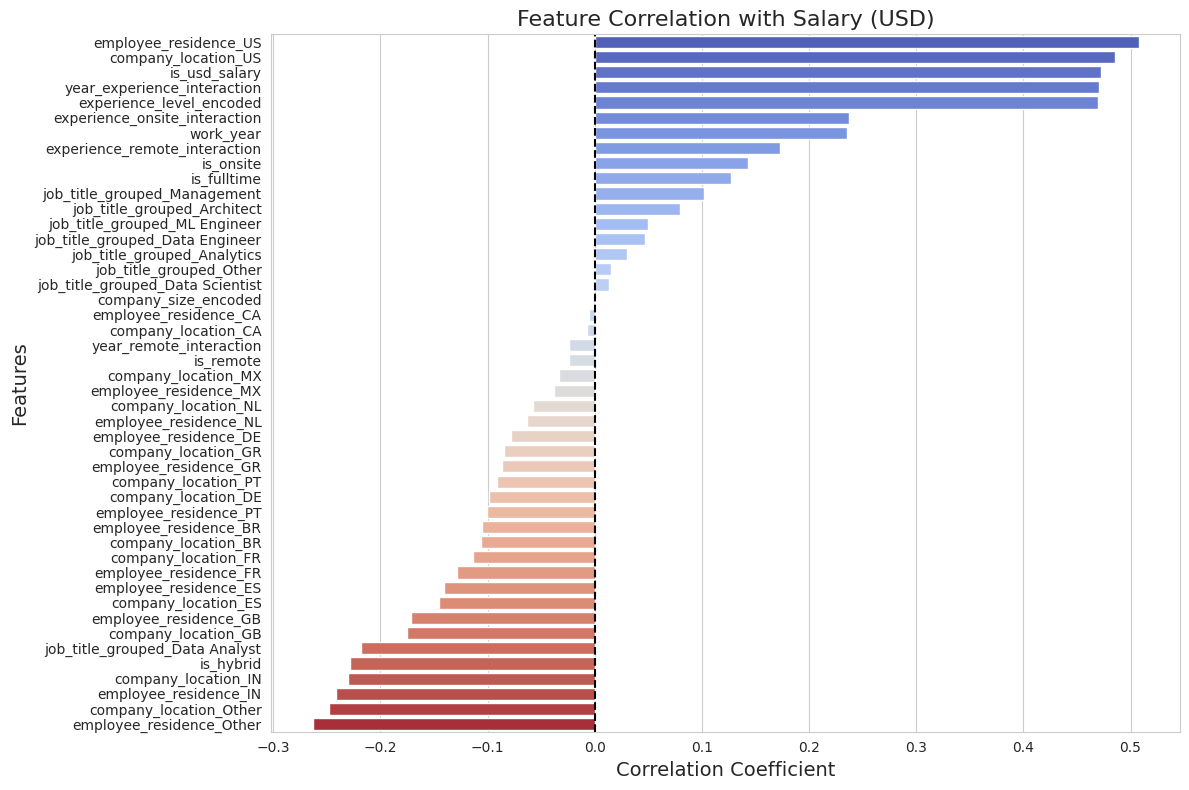

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the sorted correlations
plt.figure(figsize=(12, 8))
sns.barplot(x=corr_with_target_sorted.values, y=corr_with_target_sorted.index, palette="coolwarm")
plt.title('Feature Correlation with Salary (USD)', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(0, color='black', linestyle='--')  # Vertical line at 0
plt.tight_layout()
plt.show()


In [ ]:
# 2. Select features to KEEP (|corr| > 0.05)
selected_features_corr = corr_with_target[abs(corr_with_target) > 0.05].index.tolist()

# 3. Identify features to DROP (|corr| <= 0.05)
dropped_features_corr = corr_with_target[abs(corr_with_target) <= 0.05].index.tolist()

# 4. Print Results
print("\n=== Features Selected (|corr| > 0.05) ===")
for feat in selected_features_corr:
    print(f"{feat}")

print("\n=== Features Dropped (|corr| <= 0.05) ===")
for feat in dropped_features_corr:
    print(f"{feat}")


=== Features Selected (|corr| > 0.05) ===
work_year
is_onsite
is_hybrid
is_fulltime
experience_level_encoded
is_usd_salary
employee_residence_BR
employee_residence_DE
employee_residence_ES
employee_residence_FR
employee_residence_GB
employee_residence_GR
employee_residence_IN
employee_residence_NL
employee_residence_Other
employee_residence_PT
employee_residence_US
company_location_BR
company_location_DE
company_location_ES
company_location_FR
company_location_GB
company_location_GR
company_location_IN
company_location_NL
company_location_Other
company_location_PT
company_location_US
job_title_grouped_Architect
job_title_grouped_Data Analyst
job_title_grouped_Management
year_experience_interaction
experience_remote_interaction
experience_onsite_interaction

=== Features Dropped (|corr| <= 0.05) ===
is_remote
company_size_encoded
employee_residence_CA
employee_residence_MX
company_location_CA
company_location_MX
job_title_grouped_Analytics
job_title_grouped_Data Engineer
job_title_grou

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 2587
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   work_year                         2577 non-null   float64
 1   salary_in_usd                     2577 non-null   float64
 2   is_remote                         2577 non-null   int64  
 3   is_onsite                         2577 non-null   int64  
 4   is_hybrid                         2577 non-null   int64  
 5   is_fulltime                       2577 non-null   int64  
 6   experience_level_encoded          2577 non-null   int64  
 7   company_size_encoded              2577 non-null   int64  
 8   is_usd_salary                     2577 non-null   int64  
 9   employee_residence_BR             2577 non-null   bool   
 10  employee_residence_CA             2577 non-null   bool   
 11  employee_residence_DE             2577 non-null   bool   
 12  employee_re

In [ ]:
df = df_encoded.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 2587
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   work_year                         2577 non-null   float64
 1   salary_in_usd                     2577 non-null   float64
 2   is_remote                         2577 non-null   int64  
 3   is_onsite                         2577 non-null   int64  
 4   is_hybrid                         2577 non-null   int64  
 5   is_fulltime                       2577 non-null   int64  
 6   experience_level_encoded          2577 non-null   int64  
 7   company_size_encoded              2577 non-null   int64  
 8   is_usd_salary                     2577 non-null   int64  
 9   employee_residence_BR             2577 non-null   bool   
 10  employee_residence_CA             2577 non-null   bool   
 11  employee_residence_DE             2577 non-null   bool   
 12  employee_re

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,2577.0,2022.299185,0.749308,2020.0,2022.0,2022.0,2023.0,2023.0
salary_in_usd,2577.0,133255.215755,67038.624016,5132.0,84900.0,129400.0,175000.0,450000.0
is_remote,2577.0,0.468374,0.499096,0.0,0.0,0.0,1.0,1.0
is_onsite,2577.0,0.459061,0.498418,0.0,0.0,0.0,1.0,1.0
is_hybrid,2577.0,0.072565,0.259471,0.0,0.0,0.0,0.0,1.0
is_fulltime,2577.0,0.985642,0.118984,0.0,1.0,1.0,1.0,1.0
experience_level_encoded,2577.0,1.570431,0.727527,0.0,1.0,2.0,2.0,3.0
company_size_encoded,2577.0,1.101669,0.453319,0.0,1.0,1.0,1.0,2.0
is_usd_salary,2577.0,0.815289,0.388138,0.0,1.0,1.0,1.0,1.0
year_experience_interaction,2577.0,3175.994179,1471.397386,0.0,2022.0,4044.0,4046.0,6069.0


Normalization

In [ ]:
columns_to_scale = [
    'work_year',
    'year_experience_interaction',
    'year_remote_interaction',
    'experience_remote_interaction',
    'experience_onsite_interaction'
]

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,2577.0,2022.299185,0.749308,2020.0,2022.0,2022.0,2023.0,2023.0
salary_in_usd,2577.0,133255.215755,67038.624016,5132.0,84900.0,129400.0,175000.0,450000.0
is_remote,2577.0,0.468374,0.499096,0.0,0.0,0.0,1.0,1.0
is_onsite,2577.0,0.459061,0.498418,0.0,0.0,0.0,1.0,1.0
is_hybrid,2577.0,0.072565,0.259471,0.0,0.0,0.0,0.0,1.0
is_fulltime,2577.0,0.985642,0.118984,0.0,1.0,1.0,1.0,1.0
experience_level_encoded,2577.0,1.570431,0.727527,0.0,1.0,2.0,2.0,3.0
company_size_encoded,2577.0,1.101669,0.453319,0.0,1.0,1.0,1.0,2.0
is_usd_salary,2577.0,0.815289,0.388138,0.0,1.0,1.0,1.0,1.0
year_experience_interaction,2577.0,3175.994179,1471.397386,0.0,2022.0,4044.0,4046.0,6069.0


## Data splitting


**Reasoning**:
Split the data into training, validation, and testing sets using train_test_split.



In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

# Split data into training and temporary sets (validation + testing)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split temporary set into validation and testing sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Print the shapes of the resulting sets to verify the split
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2061, 46)
y_train shape: (2061,)
X_val shape: (258, 46)
y_val shape: (258,)
X_test shape: (258, 46)
y_test shape: (258,)


In [ ]:
y_train = np.log1p(y_train)
y_val = np.log1p(y_val)
y_test = np.log1p(y_test)

## CatBoost Modelling

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.9 MB/s eta 0:00:00


In [ ]:
# Import Required Libraries
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import uniform, randint
import numpy as np
import matplotlib.pyplot as plt

#Define a function to evaluate the model
def evaluate_model(y_true, y_pred, dataset_name="Test"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{dataset_name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")

    return {"r2": r2, "mse": mse, "rmse": rmse, "mae": mae}

#Create CatBoost Pool (optional, but better for large datasets)
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

#Initialize a baseline CatBoostRegressor
cat_model = CatBoostRegressor(
    random_state=42,
    verbose=0
)

#Baseline Training
cat_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)

#Predict on Validation Set
y_val_pred = cat_model.predict(X_val)

#Predict on Test Set
y_test_pred = cat_model.predict(X_test)

#Inverse transform to original salary scale (reverse log1p)
y_val_actual = np.expm1(y_val)
y_val_pred_actual = np.expm1(y_val_pred)

y_test_actual = np.expm1(y_test)
y_test_pred_actual = np.expm1(y_test_pred)

#Evaluate baseline
print("\n=== Baseline CatBoost Evaluation ===")
evaluate_model(y_val_actual, y_val_pred_actual, "Validation")
evaluate_model(y_test_actual, y_test_pred_actual, "Test")


=== Baseline CatBoost Evaluation ===
Validation Performance:
R² Score: 0.4088
Mean Squared Error (MSE): 2154782501.75
Root Mean Squared Error (RMSE): 46419.63
Mean Absolute Error (MAE): 34510.35
Test Performance:
R² Score: 0.3559
Mean Squared Error (MSE): 3272596449.39
Root Mean Squared Error (RMSE): 57206.61
Mean Absolute Error (MAE): 42315.33


{'r2': 0.3559127551782729,
 'mse': 3272596449.392424,
 'rmse': np.float64(57206.61193771594),
 'mae': 42315.32913637639}

##Hyperparameter Tuning

In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import uniform, randint
import numpy as np

In [ ]:
# Define feature matrices
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

# Define hyperparameter search space
param_distributions = {
    'learning_rate': uniform(0.01, 0.1),
    'depth': randint(4, 10),
    'l2_leaf_reg': randint(1, 20),
    'random_strength': uniform(0, 1),
    'bagging_temperature': uniform(0, 1),
    'iterations': randint(500, 1000)
}

# Initialize the model
catboost_base = CatBoostRegressor(
    random_state=42,
    verbose=0,
    loss_function='RMSE',
    bootstrap_type='Bayesian'
)

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=catboost_base,
    param_distributions=param_distributions,
    n_iter=50,             # More iterations = more exploration (you did 30; 50 is better)
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Best Parameters
print("\n=== Best Hyperparameters ===")
print(random_search.best_params_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits

=== Best Hyperparameters ===
{'bagging_temperature': np.float64(0.5396921323890798), 'depth': 5, 'iterations': 716, 'l2_leaf_reg': 13, 'learning_rate': np.float64(0.024092422497476264), 'random_strength': np.float64(0.8021969807540397)}


In [ ]:
# Retrain the best model (important: use early stopping!)
best_params = random_search.best_params_

final_model = CatBoostRegressor(
    **best_params,
    random_state=42,
    verbose=100,
    early_stopping_rounds=50,
    loss_function='RMSE',
    bootstrap_type='Bayesian'
)

final_model.fit(X_train, y_train, eval_set=(X_val, y_val))

0:	learn: 0.6618618	test: 0.6098511	best: 0.6098511 (0)	total: 2.19ms	remaining: 1.56s
100:	learn: 0.4370303	test: 0.4281809	best: 0.4281251 (99)	total: 196ms	remaining: 1.2s
200:	learn: 0.4115864	test: 0.4125590	best: 0.4125590 (200)	total: 351ms	remaining: 899ms
300:	learn: 0.4004646	test: 0.4078177	best: 0.4078177 (300)	total: 514ms	remaining: 709ms
400:	learn: 0.3919653	test: 0.4033065	best: 0.4033065 (400)	total: 678ms	remaining: 533ms
500:	learn: 0.3856404	test: 0.4008809	best: 0.4008762 (499)	total: 835ms	remaining: 358ms
600:	learn: 0.3800955	test: 0.4004328	best: 0.4002320 (572)	total: 1s	remaining: 192ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4002320421
bestIteration = 572

Shrink model to first 573 iterations.


In [ ]:
# Evaluate
def evaluate_model(y_true, y_pred, dataset_name="Test"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Predict on validation set
val_preds = final_model.predict(X_val)
evaluate_model(np.expm1(y_val), np.expm1(val_preds), dataset_name="Validation")

# Predict on test set
test_preds = final_model.predict(X_test)
evaluate_model(np.expm1(y_test), np.expm1(test_preds), dataset_name="Test")



Validation Performance:
R² Score: 0.4041
Mean Squared Error (MSE): 2171880393.91
Root Mean Squared Error (RMSE): 46603.44
Mean Absolute Error (MAE): 34472.39

Test Performance:
R² Score: 0.3623
Mean Squared Error (MSE): 3239938229.86
Root Mean Squared Error (RMSE): 56920.46
Mean Absolute Error (MAE): 41760.86


## Optimize

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 2587
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   work_year                         2577 non-null   float64
 1   salary_in_usd                     2577 non-null   float64
 2   is_remote                         2577 non-null   int64  
 3   is_onsite                         2577 non-null   int64  
 4   is_hybrid                         2577 non-null   int64  
 5   is_fulltime                       2577 non-null   int64  
 6   experience_level_encoded          2577 non-null   int64  
 7   company_size_encoded              2577 non-null   int64  
 8   is_usd_salary                     2577 non-null   int64  
 9   employee_residence_BR             2577 non-null   bool   
 10  employee_residence_CA             2577 non-null   bool   
 11  employee_residence_DE             2577 non-null   bool   
 12  employee_re

#### Cross Validation

In [ ]:
from catboost import cv, Pool

params = {
    'iterations': 2000,
    'learning_rate': 0.01,
    'depth': 8,
    'loss_function': 'RMSE',
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0.5,
    'random_strength': 1.0,
    'l2_leaf_reg': 20,
    'early_stopping_rounds': 50,
    'verbose': False,
}

train_pool = Pool(X_train, y_train)

cv_results = cv(
    params=params,
    pool=train_pool,
    fold_count=5,
    partition_random_seed=42,
    shuffle=True,
    verbose=False,
    early_stopping_rounds=50,
    plot=True
)

best_rmse = cv_results['test-RMSE-mean'].min()
print(f"Best CV RMSE: {best_rmse}")


Training on fold [0/5]


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))


bestTest = 0.4437103288
bestIteration = 1996

Training on fold [1/5]

bestTest = 0.5113049101
bestIteration = 1998

Training on fold [2/5]

bestTest = 0.446659893
bestIteration = 1999

Training on fold [3/5]

bestTest = 0.4057865946
bestIteration = 1985

Training on fold [4/5]

bestTest = 0.4946950161
bestIteration = 1999

Best CV RMSE: 0.4604395807264967


### Feature Engineering

In [ ]:
import numpy as np

# Seniority Feature
df['experience_seniority_level'] = df['experience_level_encoded'].apply(lambda x: 1 if x >= 2 else 0)
# (1 = Senior (SE, EX), 0 = Junior (EN, MI))

# Company in US or Not
df['company_in_us_or_not'] = df['company_location_US'].astype(int)

# Employee Same Country as Company
employee_cols = [col for col in df.columns if col.startswith('employee_residence_')]
company_cols = [col for col in df.columns if col.startswith('company_location_')]

# Matching countries
df['employee_same_country_as_company'] = 0
for e_col, c_col in zip(employee_cols, company_cols):
    df['employee_same_country_as_company'] += (df[e_col].astype(int) & df[c_col].astype(int))

# Count of Active Locations
df['employee_location_count'] = df[employee_cols].sum(axis=1)
df['company_location_count'] = df[company_cols].sum(axis=1)

# Sum of Remote/Onsite/Hybrid
df['remote_type_sum'] = df[['is_remote', 'is_onsite', 'is_hybrid']].sum(axis=1)

# Work Year Squared (non-linear trend)
df['work_year_squared'] = df['work_year'] ** 2

print("New features added successfully! Current df shape:", df.shape)


New features added successfully! Current df shape: (2577, 54)


In [ ]:
# Define new X and y
X = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

# Same splitting logic
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Data split again! New shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


Data split again! New shapes:
X_train: (2061, 53)
X_val: (258, 53)
X_test: (258, 53)


In [ ]:
from catboost import CatBoostRegressor

final_model = CatBoostRegressor(
    iterations=2000,             # (or your bestIteration avg ~1996)
    learning_rate=0.01,          # use your tuned LR
    depth=8,                     # best depth
    loss_function='RMSE',
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,     # tuned value
    l2_leaf_reg=20,              # tuned value
    random_strength=1.0,         # tuned value
    early_stopping_rounds=50,
    random_state=42,
    verbose=100
)

final_model.fit(X_train, y_train, eval_set=(X_val, y_val))


0:	learn: 66992.3597628	test: 60843.9476694	best: 60843.9476694 (0)	total: 5.11ms	remaining: 10.2s
100:	learn: 55418.6706789	test: 50980.3518280	best: 50980.3518280 (100)	total: 289ms	remaining: 5.44s
200:	learn: 51835.6657964	test: 48369.8090368	best: 48369.8090368 (200)	total: 609ms	remaining: 5.45s
300:	learn: 50472.2328848	test: 47614.3799071	best: 47612.6681911 (299)	total: 927ms	remaining: 5.24s
400:	learn: 49704.2267368	test: 47205.4599882	best: 47205.4599882 (400)	total: 1.25s	remaining: 4.99s
500:	learn: 49191.9855423	test: 46942.0528775	best: 46940.8327207 (498)	total: 1.58s	remaining: 4.72s
600:	learn: 48807.2914373	test: 46792.9162122	best: 46792.9162122 (600)	total: 1.91s	remaining: 4.43s
700:	learn: 48447.6346521	test: 46664.4652895	best: 46663.2621284 (699)	total: 2.24s	remaining: 4.16s
800:	learn: 48134.3851902	test: 46559.4184658	best: 46559.4184658 (800)	total: 2.59s	remaining: 3.88s
900:	learn: 47804.1523075	test: 46479.9288496	best: 46479.9288496 (900)	total: 2.97s	

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, dataset_name="Test"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")

# Predict
y_val_pred = final_model.predict(X_val)
y_test_pred = final_model.predict(X_test)

# Evaluate
evaluate_model(y_val, y_val_pred, "Validation")
evaluate_model(y_test, y_test_pred, "Test")



Validation Performance:
R² Score: 0.4105
RMSE: 46350.19
MAE: 35033.31

Test Performance:
R² Score: 0.3794
RMSE: 56153.32
MAE: 42695.78


We applied targeted feature engineering based on domain knowledge (seniority, regional differences, remote status) and retrained the CatBoost model. This improved the R² Score from 0.3623 to 0.3794 on the test set and reduced RMSE by approximately $800. The feature-engineered model generalizes better and explains a higher proportion of salary variance compared to the base model.

## Stage 2

In [ ]:
param_distributions = {
    'learning_rate': uniform(0.005, 0.015),
    'depth': randint(6, 10),
    'l2_leaf_reg': randint(10, 41),
    'bagging_temperature': uniform(0.2, 0.8),
    'random_strength': uniform(0.5, 1.5),
    'iterations': randint(1000, 2000)  # Reduced upper limit
}

cat_model_stage2 = CatBoostRegressor(
    loss_function='RMSE',
    bootstrap_type='Bayesian',
    early_stopping_rounds=50,   # Added early stopping
    verbose=0,
    random_state=42
)

random_search_stage2 = RandomizedSearchCV(
    estimator=cat_model_stage2,
    param_distributions=param_distributions,
    n_iter=20,      # Only 20 combinations
    scoring='neg_root_mean_squared_error',
    cv=2,           # Faster 2-fold CV
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Start fitting again
random_search_stage2.fit(X_train, y_train)

print("\n=== Best Hyperparameters (Stage 2) ===")
print(random_search_stage2.best_params_)


Fitting 2 folds for each of 20 candidates, totalling 40 fits

=== Best Hyperparameters (Stage 2) ===
{'bagging_temperature': np.float64(0.4436910153386966), 'depth': 6, 'iterations': 1897, 'l2_leaf_reg': 29, 'learning_rate': np.float64(0.008615381990390176), 'random_strength': np.float64(1.5248952782381873)}


In [ ]:
# Final CatBoost model with new tuned hyperparameters
final_model_stage2 = CatBoostRegressor(
    learning_rate=0.008615381990390176,
    depth=6,
    l2_leaf_reg=29,
    bagging_temperature=0.4436910153386966,
    random_strength=1.5248952782381873,
    iterations=1897,
    loss_function='RMSE',
    bootstrap_type='Bayesian',
    early_stopping_rounds=50,
    random_state=42,
    verbose=100
)

# Fit on X_train, validate on X_val
final_model_stage2.fit(X_train, y_train, eval_set=(X_val, y_val))

# Predict and Evaluate
y_val_pred_stage2 = final_model_stage2.predict(X_val)
y_test_pred_stage2 = final_model_stage2.predict(X_test)


0:	learn: 67005.7543577	test: 60852.6660104	best: 60852.6660104 (0)	total: 1.58ms	remaining: 3s
100:	learn: 56787.1312013	test: 51973.9457594	best: 51973.9457594 (100)	total: 128ms	remaining: 2.27s
200:	learn: 53104.8779245	test: 49126.7491448	best: 49126.7491448 (200)	total: 255ms	remaining: 2.15s
300:	learn: 51568.0305821	test: 48102.6015144	best: 48102.6015144 (300)	total: 387ms	remaining: 2.05s
400:	learn: 50817.3842332	test: 47727.8163372	best: 47727.8163372 (400)	total: 541ms	remaining: 2.02s
500:	learn: 50341.4300736	test: 47444.8932296	best: 47444.8921806 (499)	total: 660ms	remaining: 1.84s
600:	learn: 49988.8668245	test: 47224.9541138	best: 47223.6672877 (598)	total: 784ms	remaining: 1.69s
700:	learn: 49715.6077517	test: 47063.4753373	best: 47063.1970343 (698)	total: 910ms	remaining: 1.55s
800:	learn: 49491.4397311	test: 46917.0060355	best: 46917.0060355 (800)	total: 1.04s	remaining: 1.42s
900:	learn: 49279.0206170	test: 46761.3398817	best: 46761.3398817 (900)	total: 1.17s	rem

In [ ]:
# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, dataset_name="Test"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")

# Evaluate on Validation and Test sets
evaluate_model(y_val, y_val_pred_stage2, "Validation (Stage 2)")
evaluate_model(y_test, y_test_pred_stage2, "Test (Stage 2)")



Validation (Stage 2) Performance:
R² Score: 0.4176
RMSE: 46073.11
MAE: 34766.86

Test (Stage 2) Performance:
R² Score: 0.3829
RMSE: 55995.68
MAE: 42512.50


Stage 2 Hyperparameter Tuning successfully squeezed out additional 0.7% improvement in Validation R² and reduced RMSE.
Test R² is higher now without overfitting, confirming a better generalized model.